# Read csv

In [1]:
import pandas as pd

df = pd.read_excel("tennis.xlsx")

df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [6]:
type(df)

pandas.core.frame.DataFrame

# About the data

In [2]:
df.head()       # first 5 rows


,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [3]:
df.tail(3)      # last 3 rows


,outlook,temp,humidity,windy,play
11,overcast,mild,high,True,yes
12,overcast,hot,normal,False,yes
13,rainy,mild,high,True,no


In [4]:
df.sample(5)

,outlook,temp,humidity,windy,play
9,rainy,mild,normal,False,yes
7,sunny,mild,high,False,no
5,rainy,cool,normal,True,no
13,rainy,mild,high,True,no
4,rainy,cool,normal,False,yes


In [5]:
df.shape


(14, 5)

# Data types & missing values


In [7]:
df.info()       # column names, dtypes, nulls


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   outlook   14 non-null     object
 1   temp      14 non-null     object
 2   humidity  14 non-null     object
 3   windy     14 non-null     bool  
 4   play      14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


In [8]:
df.describe()   # count, mean, std, min, max

,outlook,temp,humidity,windy,play
count,14,14,14,14,14
unique,3,3,2,2,2
top,sunny,mild,high,False,yes
freq,5,6,7,8,9


In [9]:
df.isna()

,outlook,temp,humidity,windy,play
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


# Select columns

In [11]:
df["outlook"]


,outlook
0,sunny
1,sunny
2,overcast
3,rainy
4,rainy
5,rainy
6,overcast
7,sunny
8,sunny
9,rainy


In [13]:
df[["outlook", "play"]]

,outlook,play
0,sunny,no
1,sunny,no
2,overcast,yes
3,rainy,yes
4,rainy,yes
5,rainy,no
6,overcast,yes
7,sunny,no
8,sunny,yes
9,rainy,yes


In [14]:
# Filter rows
df[df["play"] == "no"]

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
5,rainy,cool,normal,True,no
7,sunny,mild,high,False,no
13,rainy,mild,high,True,no


In [17]:
df[(df["play"] == "no") & (df["outlook"] == "sunny")]

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
7,sunny,mild,high,False,no


# Some methods

In [19]:
df["play"].value_counts(normalize=True)

,proportion
play,
yes,0.642857
no,0.357143


In [23]:
#How many times people played or didn’t for each type of outlook

for group_name, group_entries in df.groupby("outlook"):
  print(group_name)
  display(group_entries)
  print()

overcast


,outlook,temp,humidity,windy,play
2,overcast,hot,high,False,yes
6,overcast,cool,normal,True,yes
11,overcast,mild,high,True,yes
12,overcast,hot,normal,False,yes



rainy


,outlook,temp,humidity,windy,play
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
9,rainy,mild,normal,False,yes
13,rainy,mild,high,True,no



sunny


,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
10,sunny,mild,normal,True,yes


In [25]:
df.groupby("outlook")["play"].value_counts()

outlook   play
overcast  yes     4
rainy     yes     3
          no      2
sunny     no      3
          yes     2
Name: count, dtype: int64

In [26]:
# how humidity interacts with outlook to affect play decisions.

df.groupby(["outlook", "humidity"])["play"].value_counts()

outlook   humidity  play
overcast  high      yes     2
          normal    yes     2
rainy     high      no      1
                    yes     1
          normal    yes     2
                    no      1
sunny     high      no      3
          normal    yes     2
Name: count, dtype: int64

In [27]:
df.groupby("outlook")["play"].apply(lambda x: (x=="yes").mean())

,play
outlook,
overcast,1.0
rainy,0.6
sunny,0.4


In [28]:
df.agg({"outlook":"count"})

,0
outlook,14


<Axes: ylabel='count'>

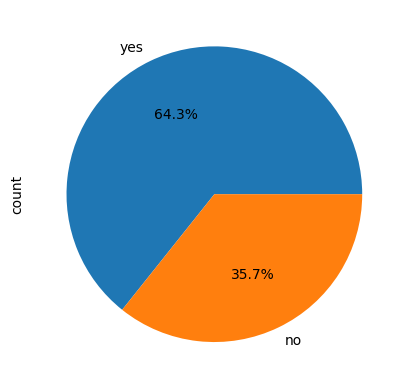

In [35]:
df["play"].value_counts().plot(kind="pie",  autopct="%1.1f%%")

In [36]:
df["play"].unique()

array(['no', 'yes'], dtype=object)

In [37]:
df["play"].nunique()

2